<a href="https://colab.research.google.com/github/IhorPetryshyn/Complex-Project/blob/main/Python_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. **SQL query to retrieve data from the database:**
select
      sp.ga_session_id,
      sp.continent,
      sp.country,
      sp.device,
      sp.browser,
      sp.mobile_model_name,
      sp.operating_system,
      sp.language,
      sp.name as source_info,
      sp.channel as traffic_source,
      acs.account_id,
      acc.is_verified,
      acc.is_unsubscribed,
      p.category,
      p.name,
      p.price,
      p.short_description,
      s.date as order_date


from `DA.session_params` sp
left join `DA.account_session` acs
on sp.ga_session_id = acs.ga_session_id
left join `DA.account` acc
on acs.account_id = acc.id
left join `DA.order` o
on sp.ga_session_id = o.ga_session_id
left join `DA.product` p
on o.item_id = p.item_id
left join `DA.session` s
on sp.ga_session_id = s.ga_session_id



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from scipy import stats
from google.colab import drive

drive.mount("/content/drive")

data = pd.read_csv("/content/drive/MyDrive/data1.csv")
df = pd.DataFrame(data)
df.info()

df["order_date"] = pd.to_datetime(df["order_date"])

print(f"Number of unique sessions: {df["ga_session_id"].nunique()}")
print(f" Analyzed period: {df["order_date"].max() - df["order_date"].min()} від {df["order_date"].min()} до {df["order_date"].max()}")

df.isna().sum()


Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ga_session_id      349545 non-null  int64  
 1   continent          349545 non-null  object 
 2   country            349545 non-null  object 
 3   device             349545 non-null  object 
 4   browser            349545 non-null  object 
 5   mobile_model_name  349545 non-null  object 
 6   operating_system   349545 non-null  object 
 7   language           235279 non-null  object 
 8   source_info        349545 non-null  object 
 9   traffic_source     349545 non-null  object 
 10  account_id         27945 non-null   float64
 11  is_verified        27945 non-null   float64
 12  is_unsubscribed    27945 non-null   float64
 13  category           33538 non-null   object 
 14  name               33538 non-null   object 
 15  price              33538 

,0
ga_session_id,0
continent,0
country,0
device,0
browser,0
mobile_model_name,0
operating_system,0
language,114266
source_info,0
traffic_source,0


* Total number of columns - 18

* Number of numerical columns (and which ones exactly) - 5 numerical columns (ga_session_id, account_id, is_verified, is_unsubscribed, price)

* Number of categorical columns (and which ones exactly) - 13 (continent, country, device, browser, mobile_model_name, operating_system, language, source_info, traffic_source, category, name, short_description, order_date)

* Number of datetime columns - currently none, but the order_date column should be in date format

* Number of unique sessions - 349545

* What time period is being considered (from... to...) - 91 days 00:00:00 (from 2020-11-01 00:00:00 to 2021-01-31 00:00:00)

* Are there missing values? - Yes, there are many missing values because not every session included an account registration or a purchase.

* Which columns have more missing values, and what is the reason? - The highest number of missing values is in the account_id, is_verified, and is_unsubscribed columns, which is even more than the missing values in the order columns. This indicates that it is not mandatory to register an account to make an order; accordingly, the number of missing values in these columns represents orders made without account registration.

 Топ 3 континенти за виручкою: 
 continent
Americas    17665280.0
Asia         7601298.3
Europe       5934624.2
Name: price, dtype: float64
 

 Топ 5 країн за виручкою: 
country
United States     13943553.9
India              2809762.0
Canada             2437921.0
United Kingdom      938317.9
France              710692.8
Name: price, dtype: float64
 

 Топ 10 категорій за виручкою: 
category
Sofas & armchairs                   8388254.5
Chairs                              6147748.8
Beds                                4919725.0
Bookcases & shelving units          3640818.1
Cabinets & cupboards                2336499.5
Outdoor furniture                   2142222.2
Tables & desks                      1790307.5
Chests of drawers & drawer units     906562.5
Bar furniture                        735503.0
Children's furniture                 467697.0
Name: price, dtype: float64
 

 Топ 10 категорій у країні за виручкою: 
category                    country      
Sofas & armchairs           Uni

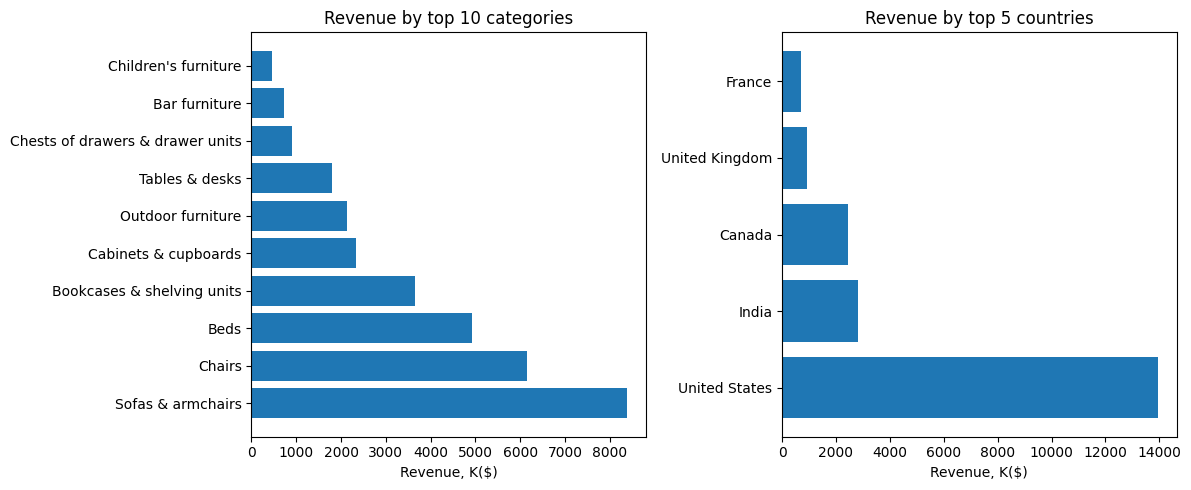

In [ ]:
continent_by_revenue = df.groupby("continent")["price"].sum().sort_values( ascending=False)
countries_by_revenue = df.groupby("country")["price"].sum().sort_values( ascending=False)

print(f" Top 3 continents by revenue: \n {continent_by_revenue.iloc[:3]}")
print(f" \n\n Top 5 countries by revenue: \n{countries_by_revenue.iloc[:5]}")

category_by_revenue = df.groupby("category")["price"].sum().sort_values(ascending=False)
print(f" \n\n Top 10 categories by revenue: \n{category_by_revenue.iloc[:10]}")

revenue_by_category_in_country = df.groupby(["category","country"])["price"].sum().sort_values(ascending=False)
print(f" \n\n Top 10 categories in a country by revenue: \n{revenue_by_category_in_country.iloc[:10]}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].barh(category_by_revenue.iloc[:10].index, category_by_revenue.iloc[:10].values / 1000)
ax[0].set_title("Revenue by top 10 categories")
ax[0].set_xlabel("Revenue, K($)")
ax[0].ticklabel_format(style='plain', axis='x')

ax[1].barh(countries_by_revenue.iloc[:5].index, countries_by_revenue.iloc[:5].values / 1000)
ax[1].set_title("Revenue by top 5 countries")
ax[1].set_xlabel("Revenue, K($)")
ax[1].ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

Most of the top positions are occupied by the US—7 out of 10 categories belong to them. However, because there are other countries with quite high revenue, the list of some categories duplicates.

% виручки за девайсами
device
desktop    59.002245
mobile     38.734924
tablet      2.262831
Name: price, dtype: float64

% виручка за джерелами трафіку
traffic_source
Organic Search    35.760189
Paid Search       26.620546
Direct            23.442345
Social Search      7.919827
Undefined          6.257093
Name: price, dtype: float64


%замовлень за девайсами
device
desktop    58.745304
mobile     39.098933
tablet      2.155764
Name: price, dtype: float64

 %замовлень за джерелами трафіку
traffic_source
Organic Search    35.544755
Paid Search       26.960463
Direct            23.257201
Social Search      8.098277
Undefined          6.139305
Name: price, dtype: float64


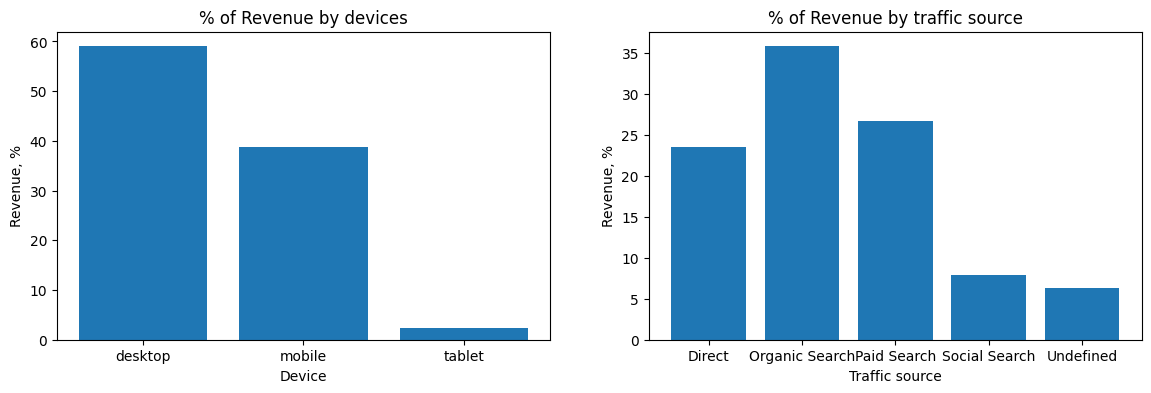

In [ ]:
revenue_perc_by_device = df.groupby("device")["price"].sum() / df["price"].sum() * 100
print(f"%of revenue by device\n{revenue_perc_by_device}")

revenue_perc_by_source = df.groupby("traffic_source")["price"].sum() / df["price"].sum() * 100
print(f"\n%of revenue by traffic source\n{revenue_perc_by_source.sort_values(ascending = False)}")

orders_perc_by_device = df.groupby("device")["price"].count() / df["price"].count() * 100
print(f"\n\n%of orders by device\n{orders_perc_by_device}")

orders_perc_by_source = df.groupby("traffic_source")["price"].count() / df["price"].count() * 100
print(f"\n %of orders by traffic source\n{orders_perc_by_source.sort_values(ascending = False)}")


fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(revenue_perc_by_device.index, revenue_perc_by_device.values)
ax[0].set_title("% of Revenue by devices")
ax[0].set_xlabel("Device")
ax[0].set_ylabel("Revenue, %")

ax[1].bar(revenue_perc_by_source.index, revenue_perc_by_source.values)
ax[1].set_title("% of Revenue by traffic source")
ax[1].set_xlabel("Traffic source")
ax[1].set_ylabel("Revenue, %")
plt.show()

Desktop devices brought the most revenue at almost 60%, followed by mobile phones at 38%. The share of tablets is only 2%.

The most profitable source is Organic Search, meaning buyers coming from a search engine who are looking for something specific. There is also a large share of revenue from search engine ads (Paid Search) and direct links (Direct)—26.6% and 23.4% respectively.

The least effective traffic source is Social Search; it attracts the fewest clients who enter similar queries into a search engine, after which they visit the site and make purchases.

Overall, all traffic sources and devices bring revenue that is proportional to the number of orders.

In [ ]:
revenue_perc_by_device_model = df.groupby("mobile_model_name")["price"].sum() / df["price"].sum() * 100
print(f"% of revenue by device models\n{revenue_perc_by_device_model.sort_values(ascending = False)}")

% виручки за моделями девайсів
mobile_model_name
Chrome        27.835602
<Other>       20.440966
Safari        20.302504
iPhone        20.082667
ChromeBook     5.725241
Edge           2.180746
iPad           1.403910
Firefox        1.316998
Pixel 4 XL     0.369976
Pixel 3        0.341390
Name: price, dtype: float64


The largest share of revenue comes from Chrome users, along with a significant share from Safari and iPhone, meaning half of the users visit the site via browsers. It might be worth reviewing the app functionality

In [ ]:
print(f"percentage of users who created an account but unsubscribed: {(df["is_unsubscribed"] == 1).sum() / df["account_id"].count() * 100} %")

відсоток користувачів, які створили аккаунт, але відписалися: 16.94399713723385 %


In [ ]:
revenue_by_subscription = df.groupby("is_unsubscribed")["price"].sum()

buyers = df[df["price"].notna()].groupby("is_unsubscribed")["account_id"].nunique()
total_users = df.groupby("is_unsubscribed")["account_id"].nunique()
purchasing_users_perc_by_sub = (buyers / total_users) * 100

print(f"Revenue from users who subscribed\n{revenue_by_subscription}")
print(f"\nPercentage of users who are either subscribed or unsubscribed and made purchases\n{purchasing_users_perc_by_sub}")



Виручка клієнтів, які підписалися
is_unsubscribed
0.0    2150796.9
1.0     431721.6
Name: price, dtype: float64

Відсоток користувачів які або підписані або відписані та робили покупки
is_unsubscribed
0.0    10.056010
1.0     9.440338
Name: account_id, dtype: float64


We can see that the ratio of buyers who are subscribed versus those who unsubscribed is practically the same, but the revenue generated by subscribed users is significantly higher. This means a subscribed user, on average, brings much higher revenue.

In [ ]:
subscribed_users_by_country = df[df["is_unsubscribed"] == 0].groupby("country")["is_unsubscribed"].count()
print(subscribed_users_by_country.sort_values(ascending=False))



country
United States        10259
India                 2203
Canada                1711
United Kingdom         735
France                 468
                     ...  
Honduras                 4
Trinidad & Tobago        4
Bahamas                  3
Mongolia                 3
Bahrain                  2
Name: is_unsubscribed, Length: 108, dtype: int64


Since subscribed users bring more revenue, I calculated their numbers broken down by country. We can see that the list of the top five countries by subscriptions is identical to the top countries by revenue.

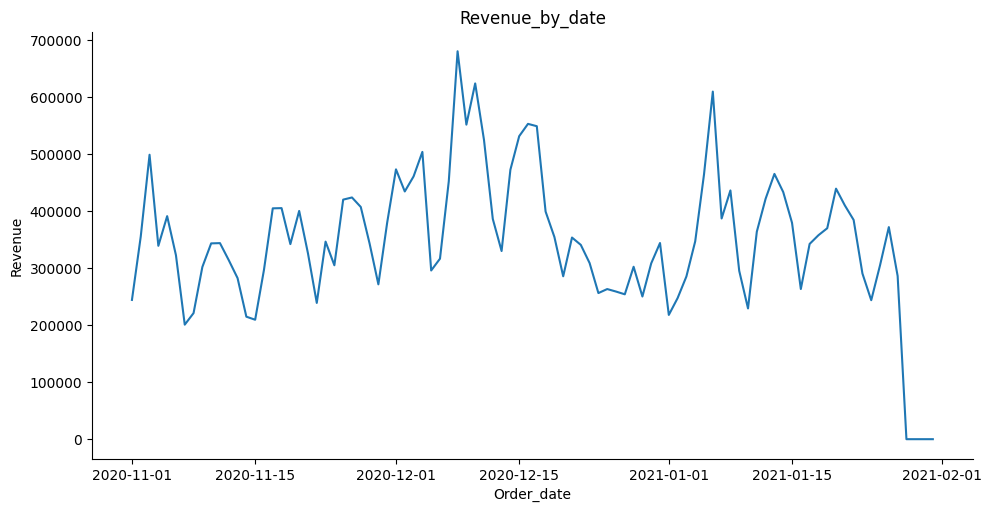

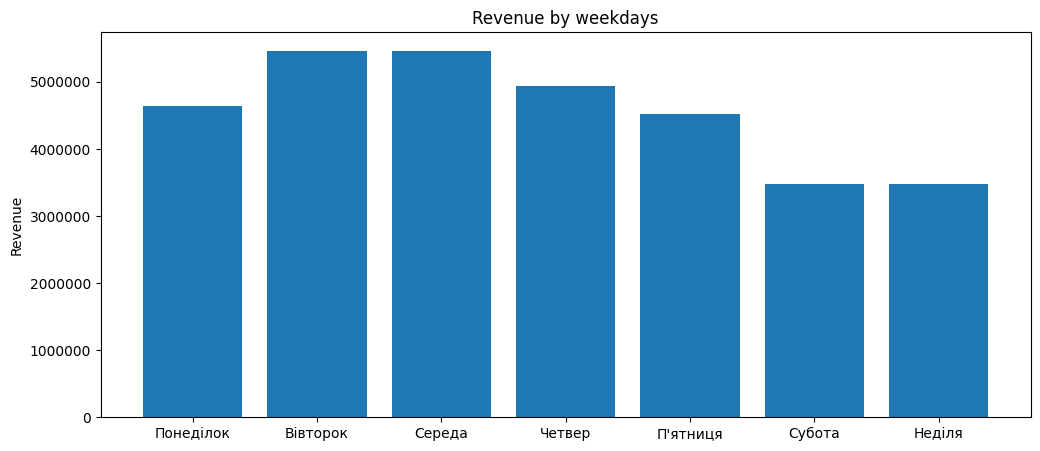

In [ ]:
revenue_by_date = df.groupby("order_date")["price"].sum().reset_index(name="revenue")

sns.relplot(x="order_date", y="revenue", kind="line", data=revenue_by_date, height = 5, aspect= 2)
plt.title("Revenue_by_date")
plt.xlabel("Order_date")
plt.ylabel("Revenue")
plt.show()

weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df["day_of_the_week"] = df["order_date"].dt.dayofweek
revenue_by_weekday = df.groupby("day_of_the_week")["price"].sum().reset_index(name="revenue")
revenue_by_weekday['day_name'] = revenue_by_weekday['day_of_the_week'].apply(lambda x: weekdays[x])

plt.figure(figsize=(12,5))
plt.bar(revenue_by_weekday["day_name"], revenue_by_weekday["revenue"])
plt.title("Revenue by weekdays")
plt.ylabel("Revenue")
plt.ticklabel_format(style='plain', axis='y')


The overall dynamics show that sales increase periodically. Based on the duration of these periods, they appear to be weekly, so it is worth looking at sales specifically broken down by days of the week. This indicates seasonality in sales, with the highest revenue on Tuesday and Wednesday, while revenue decreases on weekends. We can further analyze which specific categories are purchased the most on these days of the week.

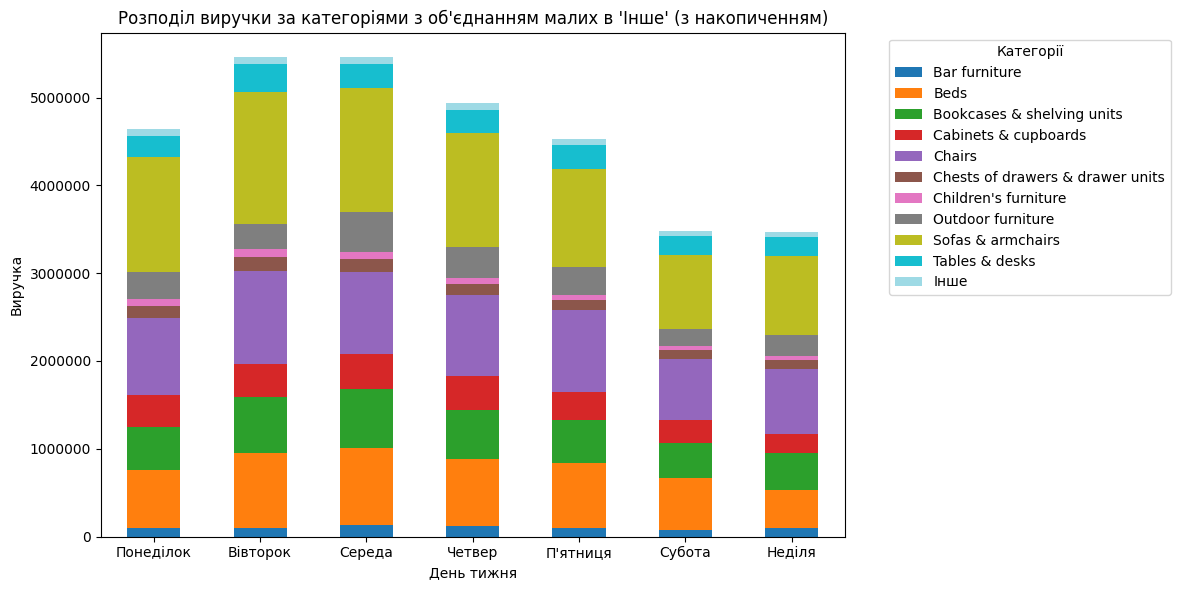

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

top_categories = df.groupby("category")["price"].sum().sort_values(ascending=False)

N = 10
top_n_names = top_categories.index[:N]
df['category_grouped'] = df['category'].apply(lambda x: x if x in top_n_names else 'Other')

category_revenue_by_weekday = df.groupby(["day_of_the_week", "category_grouped"])["price"].sum().unstack(fill_value=0)
category_revenue_by_weekday.index = [weekdays[i] for i in category_revenue_by_weekday.index]
total_revenue_by_category = category_revenue_by_weekday.sum().sort_values(ascending=True)


# 5. Побудова графіка
category_revenue_by_weekday.plot(kind='bar', stacked=True, figsize=(12, 6), cmap='tab20')

plt.title("Revenue distribution by category merging smaller ones into 'Other' (stacked)")
plt.xlabel("Day of the week")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.ticklabel_format(style='plain', axis='y')
plt.legend(title="Categories", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

That is, the seasonality is mostly driven by the sales of sofas, armchairs, and chairs due to their large share of sales, but in general, seasonality applies to all categories.

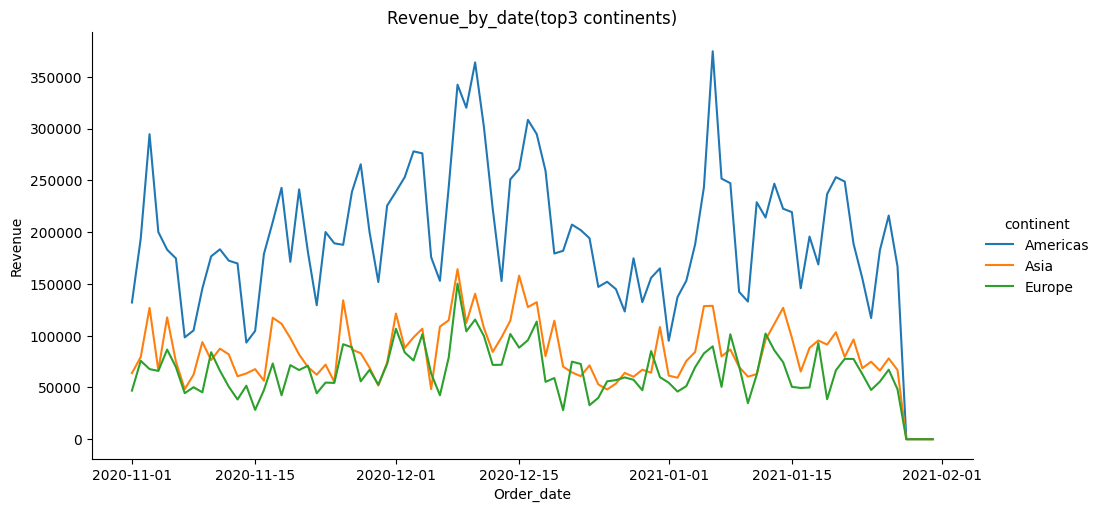

In [ ]:
df.head()
revenue_by_continent = df.groupby(["continent", "order_date"])["price"].sum().reset_index(name="revenue")

target_continents = ["Europe", "Asia", "Americas"]

filtered_revenue_by_continent = revenue_by_continent[revenue_by_continent["continent"].isin(target_continents)]

sns.relplot(x="order_date", y="revenue", kind="line", data=filtered_revenue_by_continent, height = 5, aspect= 2, hue="continent")
plt.title("Revenue_by_date(top3 continents)")
plt.xlabel("Order_date")
plt.ylabel("Revenue")
plt.show()


Of the three selected continents, the Americas brought the most revenue. The seasonality of this continent's dynamics is clearly pronounced; from mid-December 2020 to January 2021, sales dipped for the longest period, but subsequently recovered and reached a new peak. A similar pattern is observed in other continents, though the changes are less noticeable. Overall, we see that there is no stable growth on any continent, only daily seasonality.

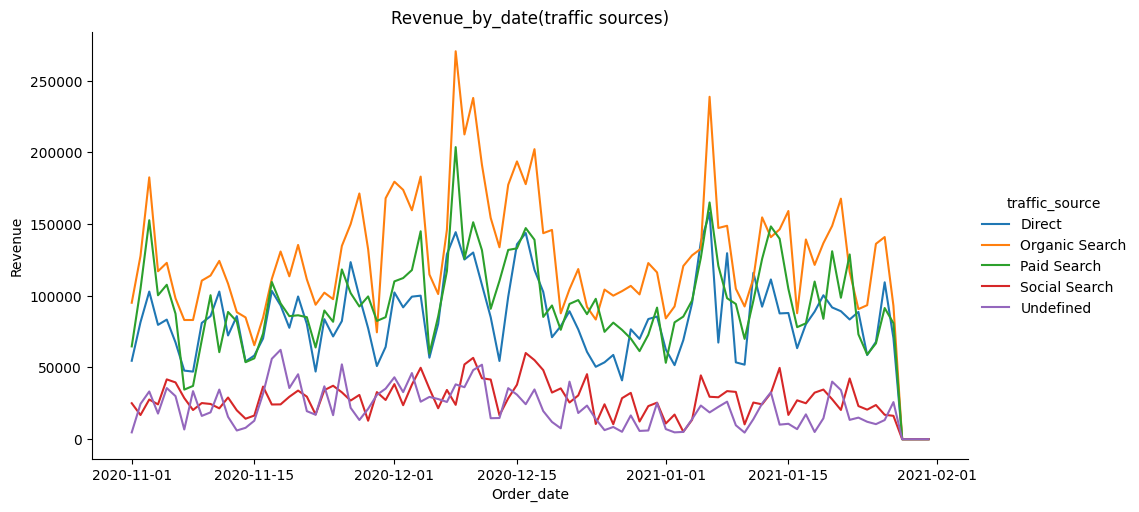

In [ ]:
df.head()
revenue_by_traffic_soutce = df.groupby(["traffic_source", "order_date"])["price"].sum().reset_index(name="revenue")

sns.relplot(x="order_date", y="revenue", kind="line", data=revenue_by_traffic_soutce, height = 5, aspect= 2, hue="traffic_source")
plt.title("Revenue_by_date(traffic sources)")
plt.xlabel("Order_date")
plt.ylabel("Revenue")
plt.show()

There is also seasonality by traffic sources. As seen from the general dynamics, there was a revenue peak in December 2020, which was largely driven by users from organic search and search engine ads. Subsequently, these two traffic sources brought fewer users, causing the overall revenue to drop. Therefore, it is worth considering expanding precisely these two traffic sources, as they yielded clear results. However, it should be taken into account that this peak could have been caused by users buying gifts before Christmas (a conclusion drawn from the date), which might not yield the same result in another period.

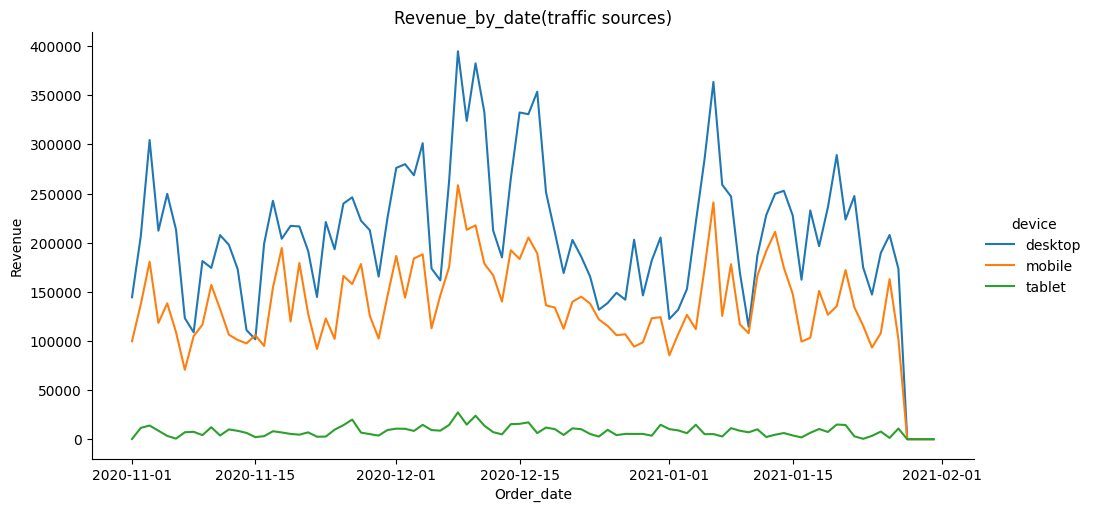

In [ ]:
df.head()
revenue_by_device = df.groupby(["device", "order_date"])["price"].sum().reset_index(name="revenue")

sns.relplot(x="order_date", y="revenue", kind="line", data=revenue_by_device, height = 5, aspect= 2, hue="device")
plt.title("Revenue_by_date(traffic sources)")
plt.xlabel("Order_date")
plt.ylabel("Revenue")
plt.show()

By devices, the dynamics for desktop and mobile are practically identical, with no obvious changes, and the seasonality for both devices is similar. Tablets remain less popular.

In [ ]:
# Pivot table of session counts by traffic source and devices
pivot_table_session_cnt = pd.pivot_table(df, values="ga_session_id", index="traffic_source", columns= "device", aggfunc="count")
print(f"Pivot table of session counts by traffic source and devices: \n{pivot_table_session_cnt} \n")


# Pivot table of revenue by categories and countries (top 10 categories and top 5 countries by revenue)
top_categories = (
    df.groupby("category")["price"].sum().nlargest(10).index
)

top_countries = (
    df.groupby("country")["price"].sum().nlargest(5).index
)

filtered_df = df[
    df["category"].isin(top_categories) & df["country"].isin(top_countries)
]

pivot_table_revenue = filtered_df.pivot_table(
    index="category",
    columns="country",
    values="price",
    aggfunc="sum",
    fill_value=0,
)
print(f"\n Pivot table of revenue by categories and countries (top 10 categories and top 5 countries by revenue): \n{pivot_table_revenue} \n")


# Pivot table of revenue by continents and traffic sources (top 3 continents by revenue)
top_continents = (
    df.groupby("continent")["price"].sum().nlargest(3).index
)

filtered_df2 = df[
    df["continent"].isin(top_continents)]

pivot_table_revenue = filtered_df.pivot_table(
    index="traffic_source",
    columns="continent",
    values="price",
    aggfunc="sum",
    fill_value=0,
)
print(f"\n Pivot table of revenue by continents and traffic sources (top 3 continents by revenue): \n{pivot_table_revenue} \n")


#Pivot table of subscribed account counts by continents

df_subscribed = df[df["is_unsubscribed"] == 0]
df_subscribed = df_subscribed.rename(
    columns={"is_unsubscribed": "subscription_status"}
)

df_subscribed["subscription_status"] = df_subscribed[
    "subscription_status"
].replace({0: "subscribed"})

pivot_table_subscription_cnt = df_subscribed.pivot_table(
    index="subscription_status",
    columns="continent",
    values="account_id",
    aggfunc="count",
    fill_value=0,
)
print(f"\n Pivot table of subscribed account counts by continents: \n{pivot_table_subscription_cnt} \n")

Зведена таблиця кількості сесій за джерелом трафіку та за девайсами: 
device          desktop  mobile  tablet
traffic_source                         
Direct            47825   31745    1812
Organic Search    72622   49014    2789
Paid Search       55167   37034    2140
Social Search     16288   10988     638
Undefined         12527    8486     470 


 Зведена таблиця виручки за категоріями та за країнами (топ 10 категорій та топ 5 країн за виручкою): 
country                             Canada    France     India  \
category                                                         
Bar furniture                      51724.0   11199.0   57657.0   
Beds                              354772.0  116414.0  358319.5   
Bookcases & shelving units        278981.9   73830.0  364507.4   
Cabinets & cupboards              181802.0   59101.5  191888.0   
Chairs                            417740.8  134029.4  544309.2   
Chests of drawers & drawer units   71952.0   21544.5   73111.0   
Children's furni

--- Статистичний звіт ---
Кількість спостережень (днів): 92
Коефіцієнт кореляції Пірсона (r): 0.7910809164540891
Статистична значущість (p-value): 6.483532312080735e-21


Text(0.5, 0, 'sessions')

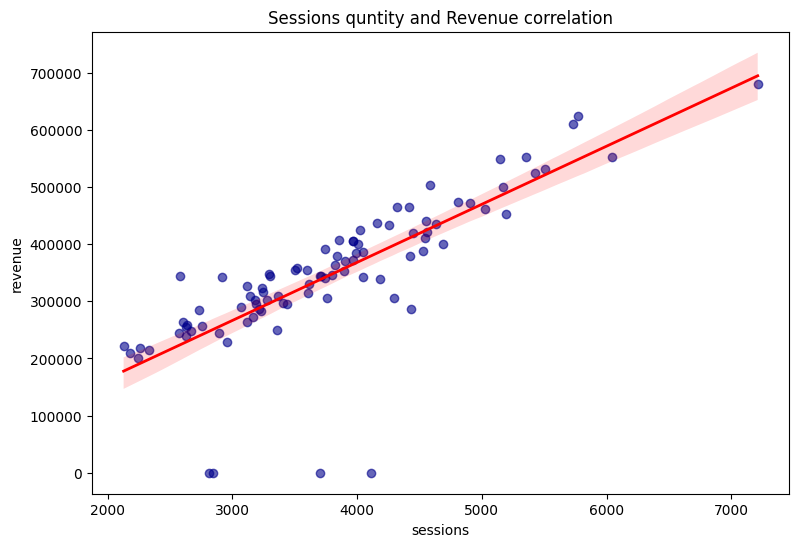

In [ ]:
session_cnt_by_date = df.groupby("order_date")["ga_session_id"].count().reset_index()
revenue_by_date = df.groupby("order_date")["price"].sum().reset_index(name="revenue")

daily_metrics = pd.merge(session_cnt_by_date, revenue_by_date, on="order_date")

corr_coef, p_value = stats.pearsonr(daily_metrics["ga_session_id"], daily_metrics["revenue"])

print("--- Statistical Report ---")
print(f"Number of observations (days): {len(daily_metrics)}")
print(f"Pearson correlation coefficient (r): {corr_coef}")
print(f"Statistical significance (p-value): {p_value}")

plt.figure(figsize=(9, 6))
sns.regplot(
    x="ga_session_id",
    y="revenue",
    data=daily_metrics,
    color="darkblue",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red", "linewidth": 2},
)
plt.title("Sessions quntity and Revenue correlation")
plt.xlabel ("sessions")

We can see that the relationship is strong and statistically significant, which is logical, meaning that a larger number of orders, as a rule, yields higher profits.

In [ ]:
top3_continents = (
    df.groupby("continent")["price"].sum().nlargest(3).index.tolist()
)
print(f"Top 3 continents for analysis: {top3_continents}\n")

df_filtered = df[df["continent"].isin(top3_continents)]

daily_revenue = (
    df_filtered.groupby(["order_date", "continent"])["price"]
    .sum()
    .reset_index(name="revenue")
)

pivot_df = daily_revenue.pivot(
    index="order_date", columns="continent", values="revenue"
).fillna(0)

print("--- CORRELATION ANALYSIS ---")

for i in range(len(top3_continents)):
    for j in range(i + 1, len(top3_continents)):
        cont1 = top3_continents[i]
        cont2 = top3_continents[j]

        r_coef, p_val = stats.pearsonr(pivot_df[cont1], pivot_df[cont2])

        print(f"Pair: {cont1} <---> {cont2}")
        print(f"  Correlation coefficient (r): {r_coef}")
        print(f"  Statistical significance (p-value): {p_val}")

        if p_val < 0.05:
            print("  Conclusion: The relationship is STATISTICALLY SIGNIFICANT (p < 0.05).")
        else:
            print("  Conclusion: The relationship is NOT STATISTICALLY SIGNIFICANT (p >= 0.05).")

        print("-" * 40)

Топ-3 континенти для аналізу: ['Americas', 'Asia', 'Europe']

--- АНАЛІЗ ВЗАЄМОЗВ'ЯЗКІВ ---
Пара: Americas <---> Asia
  Коефіцієнт кореляції (r): 0.7920245629479414
  Статистична значущість (p-value): 5.409189396197475e-21
  Висновок: Зв'язок СТАТИСТИЧНО ЗНАЧУЩИЙ (p < 0.05).
----------------------------------------
Пара: Americas <---> Europe
  Коефіцієнт кореляції (r): 0.7705864582886499
  Статистична значущість (p-value): 2.6714492240629956e-19
  Висновок: Зв'язок СТАТИСТИЧНО ЗНАЧУЩИЙ (p < 0.05).
----------------------------------------
Пара: Asia <---> Europe
  Коефіцієнт кореляції (r): 0.7684273823164164
  Статистична значущість (p-value): 3.8649460090531196e-19
  Висновок: Зв'язок СТАТИСТИЧНО ЗНАЧУЩИЙ (p < 0.05).
----------------------------------------


Sales across these three continents demonstrate a strong synchronous relationship. This indicates that common global factors (such as general seasonality or unified marketing campaigns) act upon the markets, causing sales to fluctuate simultaneously.

Знайдено джерела трафіку для аналізу: ['Direct', 'Organic Search', 'Paid Search', 'Social Search', 'Undefined']

--- АНАЛІЗ КОРЕЛЯЦІЇ ДЖЕРЕЛ ТРАФІКУ ---
Пара: Direct <---> Organic Search
  Коефіцієнт кореляції (r): 0.8378
  Статистична значущість (p-value): 0.0000
  Висновок: Зв'язок СТАТИСТИЧНО ЗНАЧУЩИЙ (p < 0.05).
--------------------------------------------------
Пара: Direct <---> Paid Search
  Коефіцієнт кореляції (r): 0.8141
  Статистична значущість (p-value): 0.0000
  Висновок: Зв'язок СТАТИСТИЧНО ЗНАЧУЩИЙ (p < 0.05).
--------------------------------------------------
Пара: Direct <---> Social Search
  Коефіцієнт кореляції (r): 0.6041
  Статистична значущість (p-value): 0.0000
  Висновок: Зв'язок СТАТИСТИЧНО ЗНАЧУЩИЙ (p < 0.05).
--------------------------------------------------
Пара: Direct <---> Undefined
  Коефіцієнт кореляції (r): 0.5175
  Статистична значущість (p-value): 0.0000
  Висновок: Зв'язок СТАТИСТИЧНО ЗНАЧУЩИЙ (p < 0.05).
-------------------------------------------

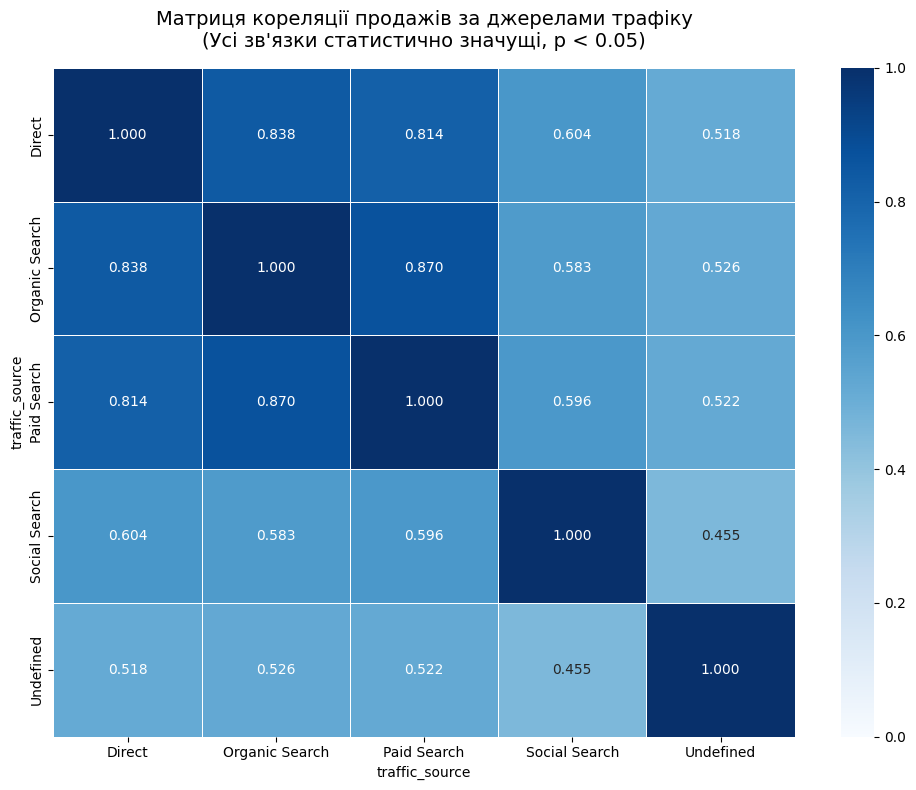

In [ ]:
traffic_source_revenue = (
    df.groupby(["traffic_source", "order_date"])["price"]
    .sum()
    .reset_index(name="revenue")
)

traffic_sources = traffic_source_revenue["traffic_source"].unique().tolist()
print(f"Found traffic sources for analysis: {traffic_sources}\n")


pivot_traffic = traffic_source_revenue.pivot(
    index="order_date", columns="traffic_source", values="revenue"
).fillna(0)

print("--- TRAFFIC SOURCES CORRELATION ANALYSIS ---")


for i in range(len(traffic_sources)):
    for j in range(i + 1, len(traffic_sources)):
        source1 = traffic_sources[i]
        source2 = traffic_sources[j]

        r_coef, p_val = stats.pearsonr(
            pivot_traffic[source1], pivot_traffic[source2]
        )

        print(f"Pair: {source1} <---> {source2}")
        print(f"  Correlation coefficient (r): {r_coef:.4f}")
        print(f"  Statistical significance (p-value): {p_val:.4f}")

        if p_val < 0.05:
            print("  Conclusion: The relationship is STATISTICALLY SIGNIFICANT (p < 0.05).")
        else:
            print("  Conclusion: The relationship is NOT STATISTICALLY SIGNIFICANT (p >= 0.05).")

        print("-" * 50)

        corr_matrix = pivot_traffic.corr()

# Heatmap for visualizing results
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    linewidths=0.5,
    vmax=1,
    vmin=0,
)

plt.title(
    "Traffic Source Sales Correlation Matrix\n(All relationships are statistically significant, p < 0.05)",
    fontsize=14,
    pad=15,
)
plt.tight_layout()

plt.show()

The project's marketing ecosystem demonstrates high integrity. Sales through Direct, Organic, and Paid Search are completely interdependent and reinforce each other ($r > 0.81$, $p < 0.05$). This indicates that advertising drives organic search, and search forms a core of loyal customers who subsequently visit the site through direct search (Direct). Any activity in one of these three channels should increase sales in adjacent sources. Social media acts more as a supporting channel.

Топ-3 континенти для аналізу: ['Sofas & armchairs', 'Chairs', 'Beds', 'Bookcases & shelving units', 'Cabinets & cupboards']

--- АНАЛІЗ ВЗАЄМОЗВ'ЯЗКІВ ---
Пара: Sofas & armchairs <---> Chairs
  Коефіцієнт кореляції (r): 0.5782483467930374
  Статистична значущість (p-value): 3.6388330532540413e-09
  Висновок: Зв'язок СТАТИСТИЧНО ЗНАЧУЩИЙ (p < 0.05).
----------------------------------------
Пара: Sofas & armchairs <---> Beds
  Коефіцієнт кореляції (r): 0.5353782861422639
  Статистична значущість (p-value): 7.687332925177328e-08
  Висновок: Зв'язок СТАТИСТИЧНО ЗНАЧУЩИЙ (p < 0.05).
----------------------------------------
Пара: Sofas & armchairs <---> Bookcases & shelving units
  Коефіцієнт кореляції (r): 0.6661941326624645
  Статистична значущість (p-value): 1.4069719486806666e-12
  Висновок: Зв'язок СТАТИСТИЧНО ЗНАЧУЩИЙ (p < 0.05).
----------------------------------------
Пара: Sofas & armchairs <---> Cabinets & cupboards
  Коефіцієнт кореляції (r): 0.6575633672296022
  Статистична значу

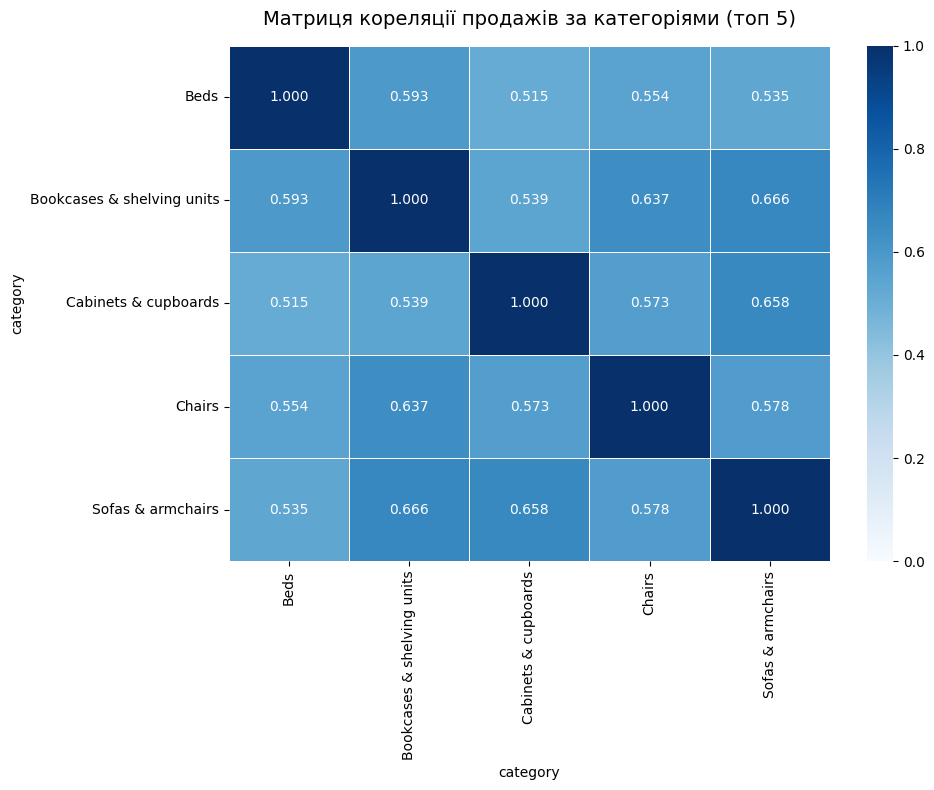

In [ ]:
top5_categories = (
    df.groupby("category")["price"].sum().nlargest(5).index.tolist()
)
# Зміна тексту в print з "Топ-3 континети" на актуальний опис топ-5 категорій
print(f"Top 5 categories for analysis: {top5_categories}\n")

df_filtered_cat = df[df["category"].isin(top5_categories)]

daily_revenue_by_cat = (
    df_filtered_cat.groupby(["order_date", "category"])["price"]
    .sum()
    .reset_index(name="revenue")
)

pivot_df_table = daily_revenue_by_cat.pivot(
    index="order_date", columns="category", values="revenue"
).fillna(0)

print("--- INTERCONNECTION ANALYSIS ---")

for i in range(len(top5_categories)):
    for j in range(i + 1, len(top5_categories)):
        cont1 = top5_categories[i]
        cont2 = top5_categories[j]

        r_coef, p_val = stats.pearsonr(pivot_df_table[cont1], pivot_df_table[cont2])

        print(f"Pair: {cont1} <---> {cont2}")
        print(f"  Correlation coefficient (r): {r_coef:.4f}")
        print(f"  Statistical significance (p-value): {p_val:.4f}")

        if p_val < 0.05:
            print("  Conclusion: The relationship is STATISTICALLY SIGNIFICANT (p < 0.05).")
        else:
            print("  Conclusion: The relationship is NOT STATISTICALLY SIGNIFICANT (p >= 0.05).")
        print("-" * 40)

# Heatmap for visualizing results
plt.figure(figsize=(10, 8))

sns.heatmap(
    pivot_df_table.corr(),
    annot=True,
    fmt=".3f",
    cmap="Blues",
    linewidths=0.5,
    vmax=1,
    vmin=0,
)

plt.title(
    "Correlation Matrix by sales category(top 5)",
    fontsize=14,
    pad=15,
)
plt.tight_layout()

plt.show()

There is no strong relationship anywhere, meaning there is no strong dependency among sales of different categories within the top 5. The highest correlation coefficient is between the bookcases & shelving units and sofas & armchairs categories; thus, it can be said that these two categories are purchased synchronously the most. Cabinets & cupboards can also be added to these two categories.

Знайдено джерела трафіку для аналізу: ['desktop', 'mobile', 'tablet']

--- АНАЛІЗ КОРЕЛЯЦІЇ девайсів ---
Пара: desktop <---> mobile
  Коефіцієнт кореляції (r): 0.8732
  Статистична значущість (p-value): 0.0000
  Висновок: Зв'язок СТАТИСТИЧНО ЗНАЧУЩИЙ (p < 0.05).
--------------------------------------------------
Пара: desktop <---> tablet
  Коефіцієнт кореляції (r): 0.6014
  Статистична значущість (p-value): 0.0000
  Висновок: Зв'язок СТАТИСТИЧНО ЗНАЧУЩИЙ (p < 0.05).
--------------------------------------------------
Пара: mobile <---> tablet
  Коефіцієнт кореляції (r): 0.5674
  Статистична значущість (p-value): 0.0000
  Висновок: Зв'язок СТАТИСТИЧНО ЗНАЧУЩИЙ (p < 0.05).
--------------------------------------------------


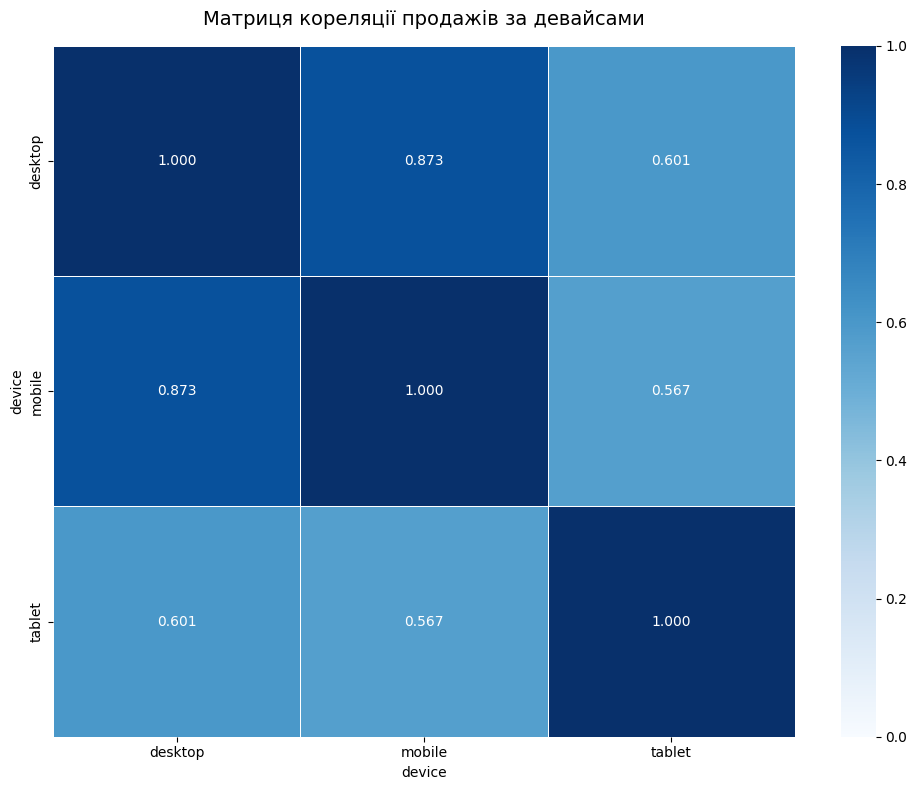

In [ ]:
device_revenue = (
    df.groupby(["device", "order_date"])["price"]
    .sum()
    .reset_index(name="revenue")
)

unique_device = device_revenue["device"].unique().tolist()
print(f"Found devices for analysis: {unique_device}\n")


device_pivot = device_revenue.pivot(
    index="order_date", columns="device", values="revenue"
).fillna(0)

print("--- DEVICE CORRELATION ANALYSIS ---")


for i in range(len(unique_device)):
    for j in range(i + 1, len(unique_device)):
        source1 = unique_device[i]
        source2 = unique_device[j]

        r_coef, p_val = stats.pearsonr(
            device_pivot[source1], device_pivot[source2]
        )

        print(f"Pair: {source1} <---> {source2}")
        print(f"  Correlation coefficient (r): {r_coef:.4f}")
        print(f"  Statistical significance (p-value): {p_val:.4f}")

        if p_val < 0.05:
            print("  Conclusion: The relationship is STATISTICALLY SIGNIFICANT (p < 0.05).")
        else:
            print("  Conclusion: The relationship is NOT STATISTICALLY SIGNIFICANT (p >= 0.05).")
        print("-" * 50)

        corr_matrix = pivot_traffic.corr()

# Теплова карта для візуалізації результатів
plt.figure(figsize=(10, 8))

sns.heatmap(
    device_pivot.corr(),
    annot=True,
    fmt=".3f",
    cmap="Blues",
    linewidths=0.5,
    vmax=1,
    vmin=0,
)

plt.title(
    "Матриця кореляції продажів за девайсами",
    fontsize=14,
    pad=15,
)
plt.tight_layout()

plt.show()

There is a strong relationship between mobile and desktop devices. This means that sales changed quite synchronously for these two categories, which suggests that there were no separate ad campaigns targeting these specific device categories. In other words, there are no imbalances favoring one type of device. As for tablets, their sales are low and the correlation coefficient is not strong, so there is no point in analyzing correlations for this device type in detail

In [ ]:
#Correlation between revenue and subscription count
df_active_subs = df[df["is_unsubscribed"] == 0]

daily_metrics = (
    df_active_subs.groupby("order_date")
    .agg(
        active_subscribers_cnt=("account_id", "nunique"),
        total_revenue=("price", "sum"),
    )
    .reset_index()
)

r_coef, p_val = stats.pearsonr(
    daily_metrics["active_subscribers_cnt"], daily_metrics["total_revenue"]
)

print("--- CORRELATION ANALYSIS RESULTS FOR SUBSCRIBED ACCOUNTS ---")
print(f"Correlation coefficient (r): {r_coef:.4f}")
print(f"Statistical significance (p-value): {p_val:.4f}")

if p_val < 0.05:
    print("Conclusion: The relationship is STATISTICALLY SIGNIFICANT (p < 0.05).")
    if r_coef > 0.7:
        print("Strong dependency")
    elif 0.3 <= r_coef <= 0.7:
        print("Moderate dependency")
    else:
        print(
            "Weak dependency"
        )
else:
    print(
        "Conclusion: The relationship is NOT statistically significant (p >= 0.05). Fluctuations in the number of subscribers and revenue are not linearly related."
    )

# Correlation of revenue and the number of accounts that are NOT subscribed
df_no_subs = df[df["is_unsubscribed"] != 0]

daily_metrics = (
    df_no_subs.groupby("order_date")
    .agg(
        no_subscribers_cnt=("account_id", "nunique"),
        total_revenue=("price", "sum"),
    )
    .reset_index()
)

r_coef, p_val = stats.pearsonr(
    daily_metrics["no_subscribers_cnt"], daily_metrics["total_revenue"]
)

print("\n--- CORRELATION ANALYSIS RESULTS FOR UNSUBSCRIBED ACCOUNTS ---")
print(f"Correlation coefficient (r): {r_coef:.4f}")
print(f"Statistical significance (p-value): {p_value:.4f}")
if p_val < 0.05:
    print("Conclusion: The relationship is STATISTICALLY SIGNIFICANT (p < 0.05).")
    if r_coef > 0.7:
        print("Strong dependency")
    elif 0.3 <= r_coef <= 0.7:
        print("Moderate dependency")
    else:
        print("Weak dependency")
else:
    print(
        "Conclusion: The relationship is NOT statistically significant (p >= 0.05). Fluctuations in the number of non-subscribers and revenue are not linearly related."
    )

--- РЕЗУЛЬТАТИ АНАЛІЗУ КОРЕЛЯЦІЇ ДЛЯ ПІДПИСАНИХ АККАУНТІВ---
Коефіцієнт кореляції (r): 0.6504
Статистична значущість (p-value): 0.0000
Висновок: Зв'язок СТАТИСТИЧНО ЗНАЧУЩИЙ (p < 0.05).
Помірна залежність

--- РЕЗУЛЬТАТИ АНАЛІЗУ КОРЕЛЯЦІЇ ДЛЯ НЕПІДПИСАНИХ АККАУНТІВ---
Коефіцієнт кореляції (r): 0.9187
Статистична значущість (p-value): 0.0000
Висновок: Зв'язок СТАТИСТИЧНО ЗНАЧУЩИЙ (p < 0.05).
Сильна залежність


Thus, as we can see, the relationship between the number of subscriptions and revenue is moderate. This is likely because a subscription does not yield immediate results; instead, the impact is more stable since these users make more predictable purchases. For context, the correlation coefficient is much stronger for unsubscribed accounts because such users are less likely to return for a repeat purchase, meaning there is a stronger immediate effect here.

Кількість днів аналізу для зареєстрованих: 88
Кількість днів аналізу для незареєстрованих: 92

Шапіро-Вілк p-value (Зареєстровані): 0.0073
Шапіро-Вілк p-value (Незареєстровані): 0.0012



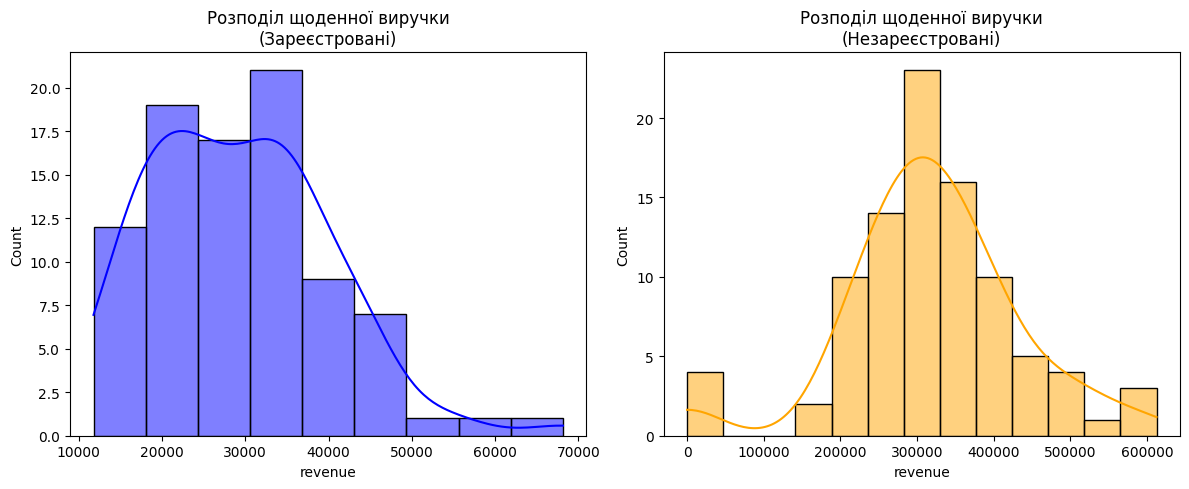

In [ ]:
daily_registered = (
    df[df["account_id"] > 0]
    .groupby("order_date")["price"]
    .sum()
    .reset_index(name="revenue")
)
daily_unregistered = (
    df[df["account_id"].isna()]
    .groupby("order_date")["price"]
    .sum()
    .reset_index(name="revenue")
)

print(
    f"Number of analysis days for registered users: {len(daily_registered)}"
)
print(
    f"Number of analysis days for unregistered users: {len(daily_unregistered)}\n"
)

# Перевірка на нормальність розподілу (Тест Шапіро-Вілка)
# Якщо p-value < 0.05, розподіл НЕ є нормальним.
_, p_shapiro_reg = stats.shapiro(daily_registered["revenue"])
_, p_shapiro_unreg = stats.shapiro(daily_unregistered["revenue"])

print(f"Shapiro-Wilk p-value (Registered): {p_shapiro_reg:.4f}")
print(f"Shapiro-Wilk p-value (Unregistered): {p_shapiro_unreg:.4f}\n")

# Візуалізація розподілів
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(daily_registered["revenue"], kde=True, color="blue")
plt.title("Daily Revenue Distribution\n(Registered Users)")

plt.subplot(1, 2, 2)
sns.histplot(daily_unregistered["revenue"], kde=True, color="orange")
plt.title("Daily Revenue Distribution\n(Unregistered Users)")

plt.tight_layout()
plt.show()

Оскільки для двох вибірок розподіл не є нормальним, бо p-value < 0.05, то для аналізу застосуємо Mann-Whitney U test

In [ ]:
stat, p_val = stats.mannwhitneyu(
    daily_registered["revenue"],
    daily_unregistered["revenue"],
    alternative="two-sided",
)

print("--- MANN-WHITNEY U TEST RESULTS ---")
print(f"U-statistic: {stat:.4f}")
print(f"Statistical significance (p-value): {p_val:.4f}\n")

# Calculate medians, as they are more informative than means for non-parametric tests
median_reg = daily_registered["revenue"].median()
median_unreg = daily_unregistered["revenue"].median()

print(f"Median daily revenue of registered users: {median_reg:.2f}")
print(f"Median daily revenue of unregistered users: {median_unreg:.2f}\n")

if p_val < 0.05:
    print(
        "CONCLUSION: The difference between the samples is STATISTICALLY SIGNIFICANT (p < 0.05)."
    )
    if median_reg > median_unreg:
        print(
            "Registered users consistently bring more daily revenue."
        )
    else:
        print(
            "Unregistered users (guests) aggregate more daily revenue."
        )
else:
    print(
        "CONCLUSION: The difference is NOT statistically significant (p >= 0.05). Current differences are accidental."
    )

--- РЕЗУЛЬТАТИ ТЕСТУ МАННА — ВІТНІ ---
Статистика U-критерію: 352.0000
Статистична значущість (p-value): 0.0000

Медіанна щоденна виручка зареєстрованих: 28048.00
Медіанна щоденна виручка незареєстрованих: 315170.75

ВИСНОВОК: Різниця між вибірками СТАТИСТИЧНО ЗНАЧУЩА (p < 0.05).
Незареєстровані користувачі (гості) сумарно генерують більше щоденної виручки.


It is worth considering expanding the base of subscribed accounts, as the moderate-to-strong correlation between revenue and the number of subscribed accounts (0.650) confirms that growing this base will positively impact overall revenue. The effect of driving subscriptions will be cumulative—the results won't appear instantly, but rather as growth in stable, long-term revenue (LTV). However, incentivizing subscriptions should be handled carefully to avoid creating barriers for unsubscribed users, as this segment currently delivers the fastest impact (0.9187) on daily sales during marketing campaigns.

Шапіро-Вілк p-value:0.0000
--- РЕЗУЛЬТАТИ ТЕСТУ КРУСКАЛА — ВОЛЛІСА ---
Статистика критерію H: 368.9806
Статистична значущість (p-value): 0.0000



/tmp/ipykernel_504/2786750412.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


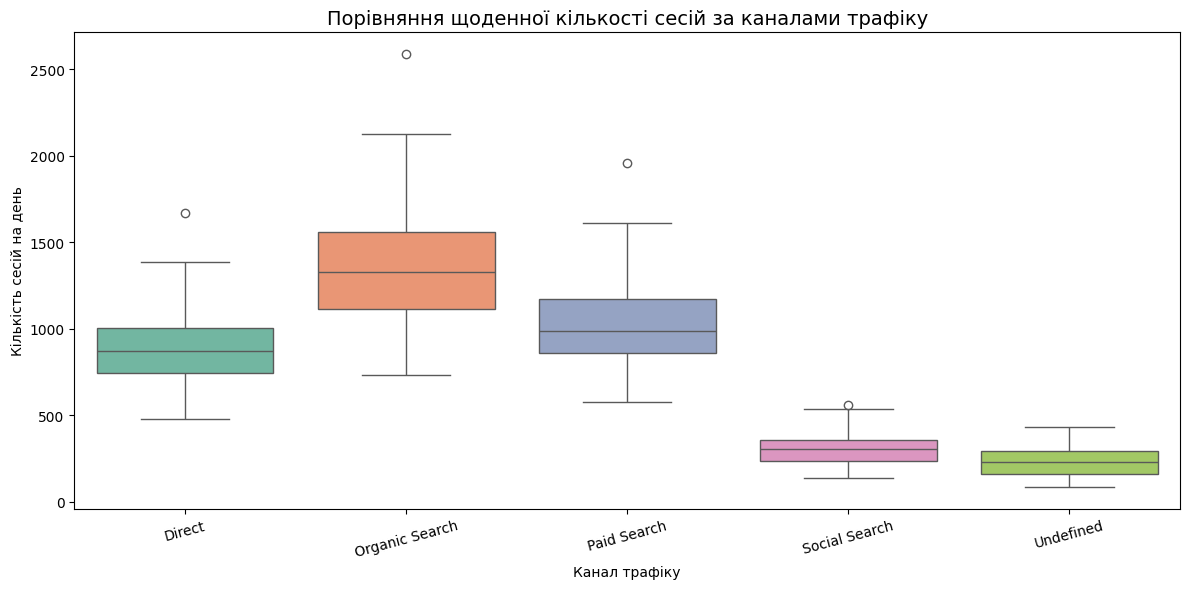

In [ ]:
session_cnt_traffic = df.groupby(["order_date", "traffic_source"])["ga_session_id"].nunique().reset_index(name="session_count")
channels = session_cnt_traffic["traffic_source"].unique()
groups = [
    session_cnt_traffic[
        session_cnt_traffic["traffic_source"] == channel
    ]["session_count"]
    for channel in channels
]

_, p_shapiro_reg = stats.shapiro(session_cnt_traffic["session_count"])
print(f"Shapiro-Wilk p-value: {p_shapiro_reg:.4f}")

stat, p_val = stats.kruskal(*groups)

print("--- KRUSKAL-WALLIS TEST RESULTS ---")
print(f"H-statistic: {stat:.4f}")
print(f"Statistical significance (p-value): {p_val:.4f}\n")

# Visualization for difference analysis (Boxplot)
plt.figure(figsize=(12, 6))
sns.boxplot(
    x="traffic_source",
    y="session_count",
    data=session_cnt_traffic,
    palette="Set2"
)
plt.title(
    "Comparison of Daily Session Counts Across Traffic Channels", fontsize=14
)
plt.xlabel("Traffic Channel")
plt.ylabel("Number of Sessions per Day")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Visual analysis and pairwise comparisons of daily session distributions confirm the presence of statistically significant differences between most traffic channels. Organic Search is the absolute leader in terms of session generation volume, significantly outperforming paid traffic (Paid Search) and direct visits (Direct). Paid Search and Direct form the second-tier traffic volume, demonstrating relatively close yet statistically distinct levels. This indicates that the structure of customer acquisition on the platform is heterogeneous, and the primary reliance of the e-commerce ecosystem currently rests on search (organic and paid) traffic.


In [ ]:
# Since organic search brings the most traffic, and among continents, the Americas and Europe generate the most revenue, it is worth comparing whether there is a difference in the share of organic traffic between these two continents.
continent_filter = df[df["continent"].isin(["Americas", "Europe"])]

continent_filter["is_organic"] = continent_filter["traffic_source"].apply(
    lambda x: "Organic Search" if x == "Organic Search" else "Other"
)

contingency_table = pd.crosstab(
    continent_filter["continent"], continent_filter["is_organic"]
)

print("--- INPUT DATA FOR THE TEST (CONTINGENCY TABLE) ---")
print(contingency_table, "\n")

proportions = pd.crosstab(
    continent_filter["continent"], continent_filter["is_organic"], normalize="index"
)

print("--- SHARES (PROPORTIONS) BY CONTINENTS ---")
print(proportions, "\n")

chi2_stat, p_val, dof, expected = stats.chi2_contingency(contingency_table)

print("--- STATISTICAL TEST RESULTS ---")
print(f"Chi-square Statistic: {chi2_stat:.4f}")
print(f"Statistical significance (p-value): {p_val:.4f}\n")

print("--- FINAL CONCLUSION ---")
if p_val < 0.05:
    print(
        "The difference in the share of organic traffic between Europe and the Americas is STATISTICALLY SIGNIFICANT (p < 0.05)."
    )
    eur_organic = proportions.loc["Europe", "Organic Search"] * 100
    # Виправлено "North America" -> "Americas" відповідно до вашого DataFrame
    am_organic = proportions.loc["Americas", "Organic Search"] * 100
    print(
        f"Share in Europe: {eur_organic:.2f}%, share in the Americas: {am_organic:.2f}%"
    )
else:
    print(
        "The difference in the share of organic traffic is NOT statistically significant (p >= 0.05). The deviations are accidental."
    )

--- ВХІДНІ ДАНІ ДЛЯ ТЕСТУ (ТАБЛИЦЯ СПРЯЖЕНОСТІ) ---
is_organic  Organic Search   Other
continent                         
Americas             68671  124508
Europe               23195   41940 

--- ЧАСТКИ (ПРОПОРЦІЇ) ЗА КОНТИНЕНТАМИ ---
is_organic  Organic Search     Other
continent                           
Americas          0.355479  0.644521
Europe            0.356107  0.643893 

--- РЕЗУЛЬТАТИ СТАТИСТИЧНОГО ТЕСТУ ---
Статистика Хі-квадрат: 0.0811
Статистична значущість (p-value): 0.7758

--- ФІНАЛЬНИЙ ВИСНОВОК ---
Різниця у долі органічного трафіку НЕ Є статистично значущою (p >= 0.05). Відхилення випадкові.


/tmp/ipykernel_504/3582161293.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  continent_filter["is_organic"] = continent_filter["traffic_source"].apply(


That is, there is no statistically significant difference in the share of sessions driven by organic search between Europe and the Americas. Furthermore, it is also worth investigating the difference in the share of sessions converted into subscriptions, as this will reveal which traffic is more effective.

In [ ]:
df_users = df[
    (df["account_id"] > 0) & (df["continent"].isin(["Americas", "Europe"]))
].copy()

df_users["subscription_status"] = df_users["is_unsubscribed"].replace(
    {0: "Active Subscriber", 1: "Unsubscribed/No Sub"}
)

sub_contingency = pd.crosstab(
    df_users["continent"], df_users["subscription_status"]
)

print("--- CONTINGENCY TABLE (ACCOUNT COUNT) ---")
print(sub_contingency, "\n")

sub_proportions = pd.crosstab(
    df_users["continent"], df_users["subscription_status"], normalize="index"
)

print("--- SHARES (CONVERSION TO SUBSCRIPTION) ---")
print(sub_proportions, "\n")

chi2_stat, p_val, dof, expected = stats.chi2_contingency(sub_contingency)

print("--- CHI-SQUARE TEST RESULTS FOR CONVERSION ---")
print(f"Chi-square Statistic: {chi2_stat:.4f}")
print(f"p-value: {p_val:.4f}\n")

if p_val < 0.05:
    print(
        "CONCLUSION: The difference in conversion between continents is STATISTICALLY SIGNIFICANT (p < 0.05)."
    )
    am_sub = sub_proportions.loc["Americas", "Active Subscriber"] * 100
    eu_sub = sub_proportions.loc["Europe", "Active Subscriber"] * 100
    print(
        f"Conversion in the Americas: {am_sub:.2f}%. Conversion in Europe: {eu_sub:.2f}%"
    )
else:
    print(
        "CONCLUSION: The difference in conversion is NOT statistically significant (p >= 0.05). Subscription loyalty in both regions is at the same level."
    )


--- ТАБЛИЦЯ СПРЯЖЕНОСТІ (КІЛЬКІСТЬ АКАУНТІВ) ---
subscription_status  Active Subscriber  Unsubscribed/No Sub
continent                                                  
Americas                         12874                 2646
Europe                            4328                  842 

--- ЧАСТКИ (КОНВЕРСІЯ В ПІДПИСКУ) ---
subscription_status  Active Subscriber  Unsubscribed/No Sub
continent                                                  
Americas                      0.829510             0.170490
Europe                        0.837137             0.162863 

--- РЕЗУЛЬТАТИ ТЕСТУ ХІ-КВАДРАТ ДЛЯ КОНВЕРСІЇ ---
Статистика Хі-квадрат: 1.5556
p-value: 0.2123

ВИСНОВОК: Різниця в конверсії НЕ Є статистично значущою (p >= 0.05). Лояльність до підписок в обох регіонах на одному рівні.


##GENERAL CONCLUSION
Based on the results of the e-commerce data analysis, the market structure, customer behavior, and the effectiveness of the project's marketing ecosystem were investigated.

1. Geography and Seasonality
* USA and the Americas are key markets: The Americas continent generates the highest revenue, and the USA occupies 7 out of 10 positions in the top countries list.

* Weekly cyclicity: The peak of sales consistently falls on Tuesday and Wednesday, while demand drops on weekends. This effect is mostly driven by product leaders in sales: sofas, armchairs, and chairs.

* Calendar peaks: The highest revenue was recorded in December (the Christmas period), followed by a prolonged January slump. There is no linear growth—the dynamics are purely seasonal.

2. Devices and Interfaces
* Desktop Priority: Desktops account for ~60% of revenue, mobile devices for 38%, while tablets take up only 2%.
* Channel Synchronicity: Sales dynamics on smartphones and PCs align completely. Since half of the transitions come through Chrome, Safari, and iPhone, it is recommended to optimize mobile functionality (UX/UI) to increase conversion rates from phones.
3. Marketing Ecosystem
* Primary Channels: The majority of revenue is driven by Organic Search (the absolute leader in sessions), Paid Search (26.6% of revenue), and Direct (23.4%).
* СChannel Synergy: A strong correlation was detected ($r > 0.81$). Advertising (Paid) stimulates organic search (Organic), which subsequently converts into direct visits (Direct). Activity in one channel reinforces the others.
* Underperformer: Social Search is the least effective source for customer acquisition.
4. Interconnection of Categories
* In general, product categories sell independently. However, the highest synchronicity in sales is noticeable between bookcases, seating furniture (sofas/armchairs), and cabinets. This indicates strong potential for cross-selling.
5. Subscription Economics (LTV vs. Quick Revenue)
* Value of Subscribers: The number of subscribed and unsubscribed users is equal, but subscribed ones bring significantly higher revenue (higher LTV and stability). The top 5 countries by subscriptions are identical to the top countries by revenue.
* Segment Balance: The number of subscriptions has a moderate correlation with income ($r = 0.650$) and works for the long-term perspective. At the same time, unsubscribed accounts are critically important for quick sales during promotions ($r = 0.918$).
## STRATEGIC RECOMMENDATIONS
* Focus on Search: Maximize support for SEO (Organic) and PPC (Paid Search), which provide the main scale for the platform.

* Mobile Optimization: Improve the interface for Safari/iPhone users to better monetize the 38% of mobile traffic.

* Smart Subscriptions: Incentivize clients to subscribe after their first purchase to drive LTV growth, but avoid creating rigid barriers for new (unsubscribed) buyers who provide quick liquidity during sale periods.

* Cross-Marketing: Create ready-made furniture bundles (sofas + cabinets/shelves) based on their shared purchasing patterns.

Link to the Tableau dashboard: https://public.tableau.com/app/profile/ihor.petrsyhyn/viz/Portfolio1_17817002319700/additionaldashboard?publish=yes